Found 3600 images belonging to 5 classes.
Found 76 images belonging to 5 classes.
Found 81 images belonging to 5 classes.
Epoch 1/20
57/57 [==============================] - 44s 507ms/step - loss: 2.7881 - accuracy: 0.3344 - val_loss: 2.1959 - val_accuracy: 0.5395 - lr: 0.0010
Epoch 2/20
57/57 [==============================] - 10s 178ms/step - loss: 2.0713 - accuracy: 0.4875 - val_loss: 1.9930 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/20
57/57 [==============================] - 10s 178ms/step - loss: 1.7449 - accuracy: 0.6256 - val_loss: 2.0287 - val_accuracy: 0.5395 - lr: 0.0010
Epoch 4/20
57/57 [==============================] - 10s 178ms/step - loss: 1.4472 - accuracy: 0.7353 - val_loss: 2.0545 - val_accuracy: 0.6447 - lr: 0.0010
Epoch 5/20
57/57 [==============================] - 10s 178ms/step - loss: 1.2089 - accuracy: 0.8131 - val_loss: 2.0516 - val_accuracy: 0.6184 - lr: 0.0010
Epoch 6/20
57/57 [==============================] - 10s 179ms/step - loss: 1.0048 - accuracy: 0.88

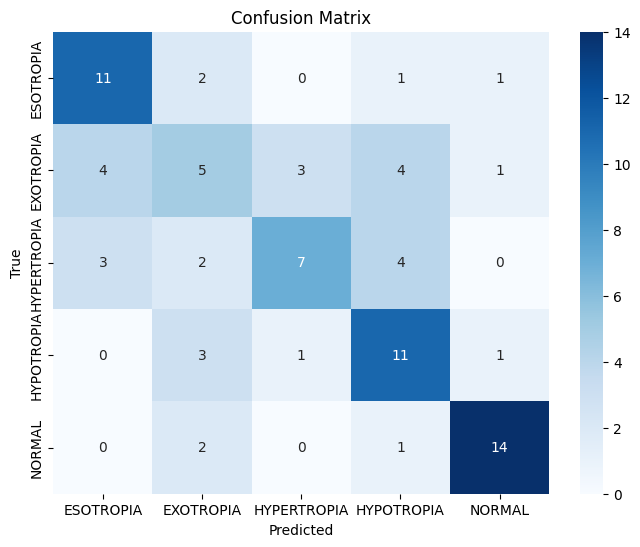

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Dataset paths
data_train = "E:/Projects/Strabismus/Final_Train_data"
data_val = "E:/Projects/Strabismus/Split_Data/val"
data_test = "E:/Projects/Strabismus/Split_Data/test"

# Image parameters
img_height, img_width = 224, 224
batch_size = 64
num_classes = 5

# Data Augmentation
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input)

train_generator = datagen.flow_from_directory(data_train, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical')
val_generator = datagen.flow_from_directory(data_val, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical')
test_generator = datagen.flow_from_directory(data_test, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=False)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# Load VGG19 model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  

# Custom model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 15:
        return lr * 0.5
    else:
        return lr * 0.1

callback_lr = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Train model
model.fit(train_generator, epochs=20, validation_data=val_generator, class_weight=class_weight_dict, callbacks=[callback_lr, reduce_lr, early_stopping])

# Fine-tune model
for layer in base_model.layers[10:]:  
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(train_generator, epochs=30, validation_data=val_generator, class_weight=class_weight_dict, callbacks=[callback_lr, reduce_lr, early_stopping])

# Evaluate on test set
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
